In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
import shap

os.makedirs('outputs', exist_ok=True)
os.makedirs('model',   exist_ok=True)

In [47]:
df1 = pd.read_csv('healthcare-dataset-stroke-data.csv')
df2 = pd.read_csv('brain_stroke.csv')


if 'id' in df1.columns:
    df1 = df1.drop(columns=['id'])

print(f'Kaggle dataset (full)      : {len(df1):,} rows '
      f'({df1["stroke"].sum()} strokes)')


brain_strokes = df2[df2['stroke'] == 1].copy()
print(f'Brain_stroke stroke cases  : {len(brain_strokes):,}')


data = pd.concat([df1, brain_strokes], ignore_index=True)
print(f'Combined (before dedup)    : {len(data):,} rows '
      f'({data["stroke"].sum()} strokes)')

data['age']               = data['age'].round(0)
data['bmi']               = data['bmi'].round(1)
data['avg_glucose_level'] = data['avg_glucose_level'].round(1)


dedup_cols = ['gender', 'age', 'hypertension', 'heart_disease',
              'ever_married', 'work_type', 'Residence_type',
              'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

before = len(data)
data.drop_duplicates(subset=dedup_cols, keep='first', inplace=True)
data.reset_index(drop=True, inplace=True)

print(f'Combined (after dedup)     : {len(data):,} rows '
      f'({data["stroke"].sum()} strokes)')
print(f'Duplicates removed         : {before - len(data):,}')
print(f'\nFinal stroke rate          : {data["stroke"].mean()*100:.2f}%')

display(data.info(), data.head())

Kaggle dataset (full)      : 5,110 rows (249 strokes)
Brain_stroke stroke cases  : 248
Combined (before dedup)    : 5,358 rows (497 strokes)
Combined (after dedup)     : 5,150 rows (289 strokes)
Duplicates removed         : 208

Final stroke rate          : 5.61%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5150 non-null   object 
 1   age                5150 non-null   float64
 2   hypertension       5150 non-null   int64  
 3   heart_disease      5150 non-null   int64  
 4   ever_married       5150 non-null   object 
 5   work_type          5150 non-null   object 
 6   Residence_type     5150 non-null   object 
 7   avg_glucose_level  5150 non-null   float64
 8   bmi                4949 non-null   float64
 9   smoking_status     5150 non-null   object 
 10  stroke             5150 non-null   int64  
dtype

None

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.7,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.2,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.9,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.2,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.1,24.0,never smoked,1


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5150 non-null   object 
 1   age                5150 non-null   float64
 2   hypertension       5150 non-null   int64  
 3   heart_disease      5150 non-null   int64  
 4   ever_married       5150 non-null   object 
 5   work_type          5150 non-null   object 
 6   Residence_type     5150 non-null   object 
 7   avg_glucose_level  5150 non-null   float64
 8   bmi                4949 non-null   float64
 9   smoking_status     5150 non-null   object 
 10  stroke             5150 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 442.7+ KB


In [49]:
display(data.describe().round(2))

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5150.00,5150.0,5150.00,5150.00,4949.00,5150.00
mean,43.42,0.1,0.05,106.27,28.90,0.06
std,22.66,0.3,0.23,45.42,7.83,0.23
min,0.00,0.0,0.00,55.10,10.30,0.00
25%,25.00,0.0,0.00,77.20,23.60,0.00
50%,45.00,0.0,0.00,91.90,28.10,0.00
75%,61.00,0.0,0.00,114.20,33.00,0.00
max,82.00,1.0,1.00,271.70,97.60,1.00


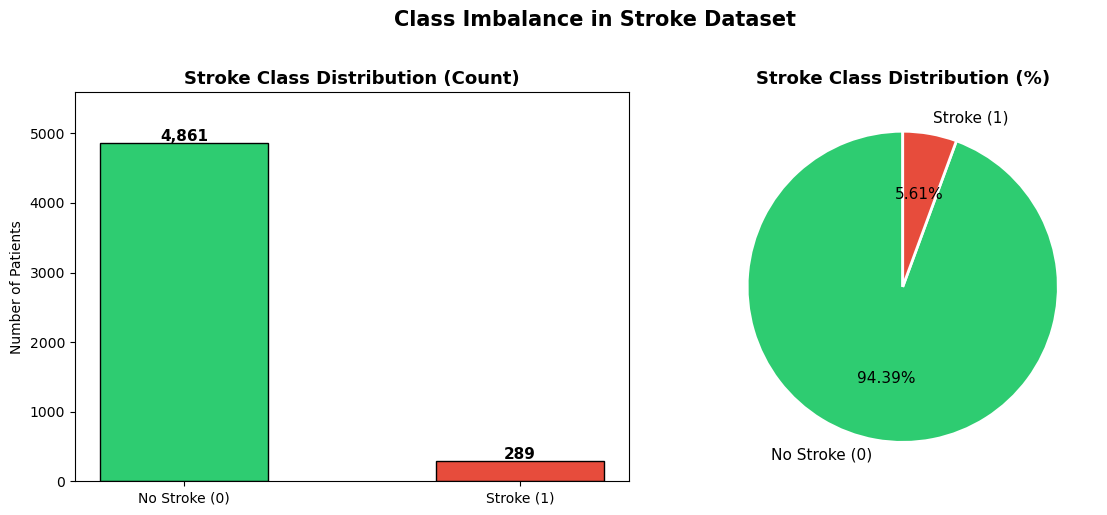

In [50]:
stroke_counts = data['stroke'].value_counts()
stroke_pct    = data['stroke'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No Stroke (0)', 'Stroke (1)'], stroke_counts.values, color=colors, edgecolor='black', width=0.5)
for i, v in enumerate(stroke_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Stroke Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, stroke_counts[0] * 1.15)

axes[1].pie(stroke_counts.values, labels=['No Stroke (0)', 'Stroke (1)'],
            colors=colors, autopct='%1.2f%%', startangle=90,
            textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Stroke Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance in Stroke Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./outputs/01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

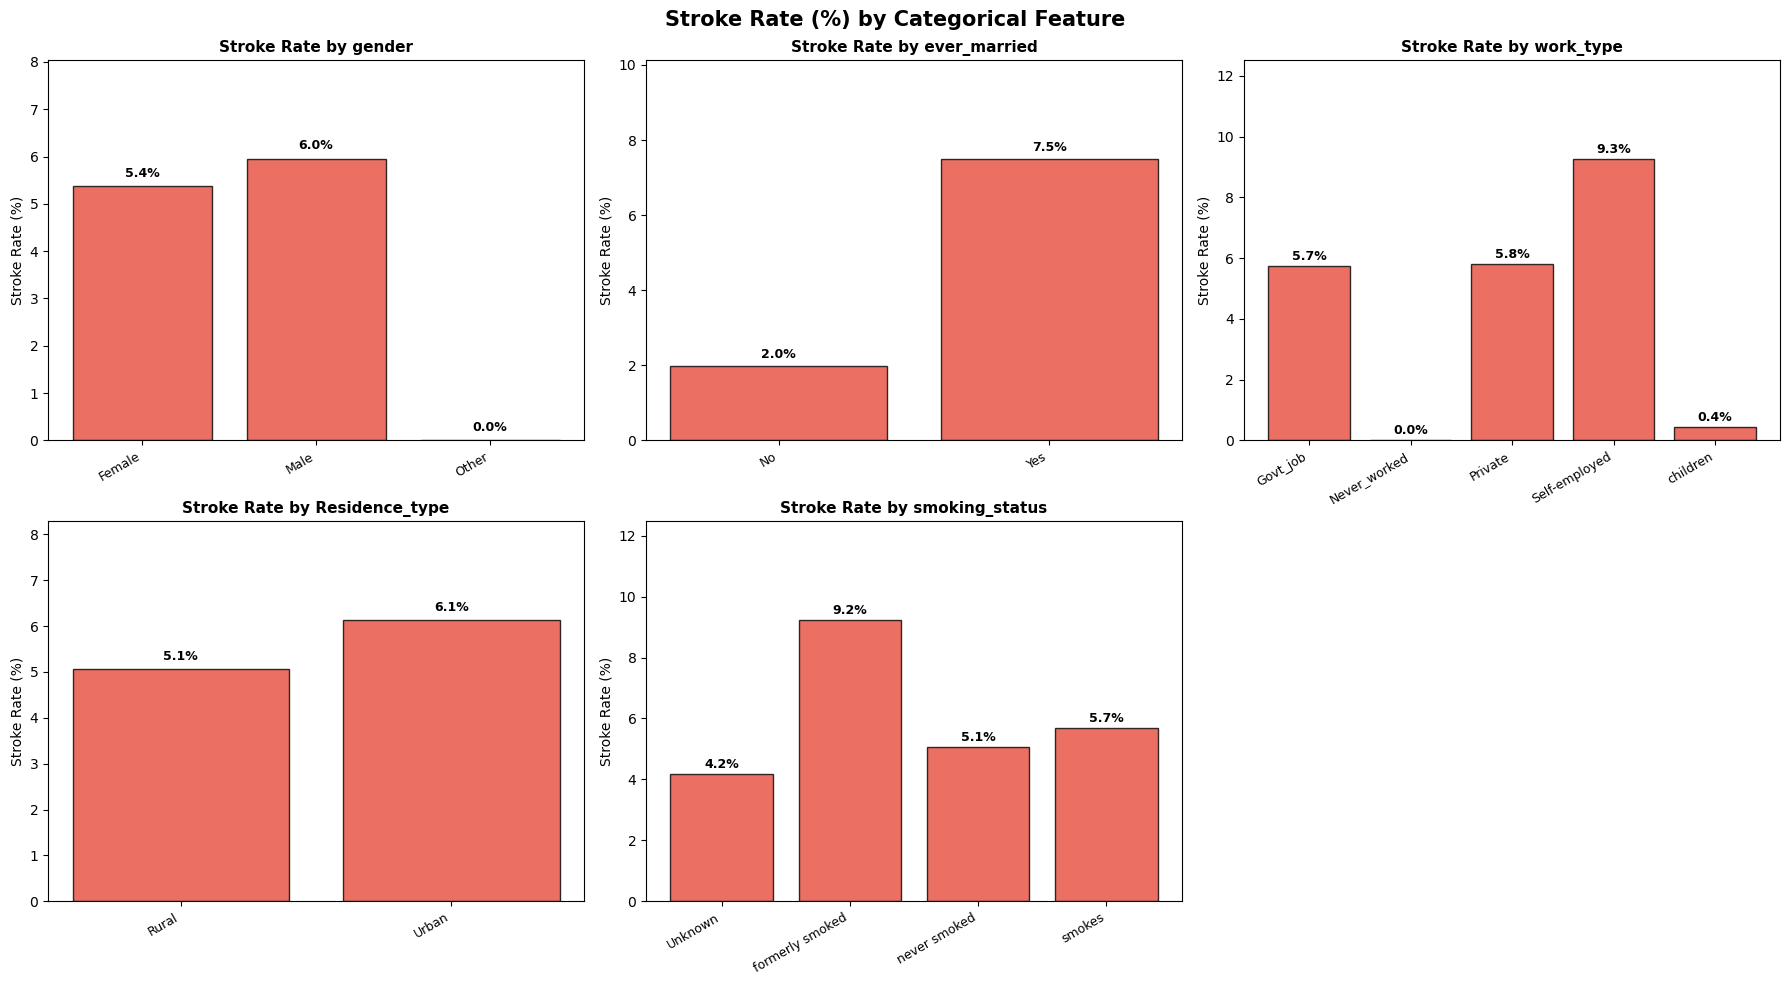

In [51]:
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    ax = axes[idx]
    
    stroke_rate = data.groupby(feature)['stroke'].mean() * 100
    counts      = data.groupby(feature)['stroke'].count()

    # bar plot of stroke rate
    bars = ax.bar(stroke_rate.index, stroke_rate.values,
                  color='#e74c3c', alpha=0.8, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Stroke Rate by {feature}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Stroke Rate (%)')
    ax.set_xticklabels(stroke_rate.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, stroke_rate.max() * 1.35)

axes[-1].set_visible(False)  # hide unused subplot
plt.suptitle('Stroke Rate (%) by Categorical Feature', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/01_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


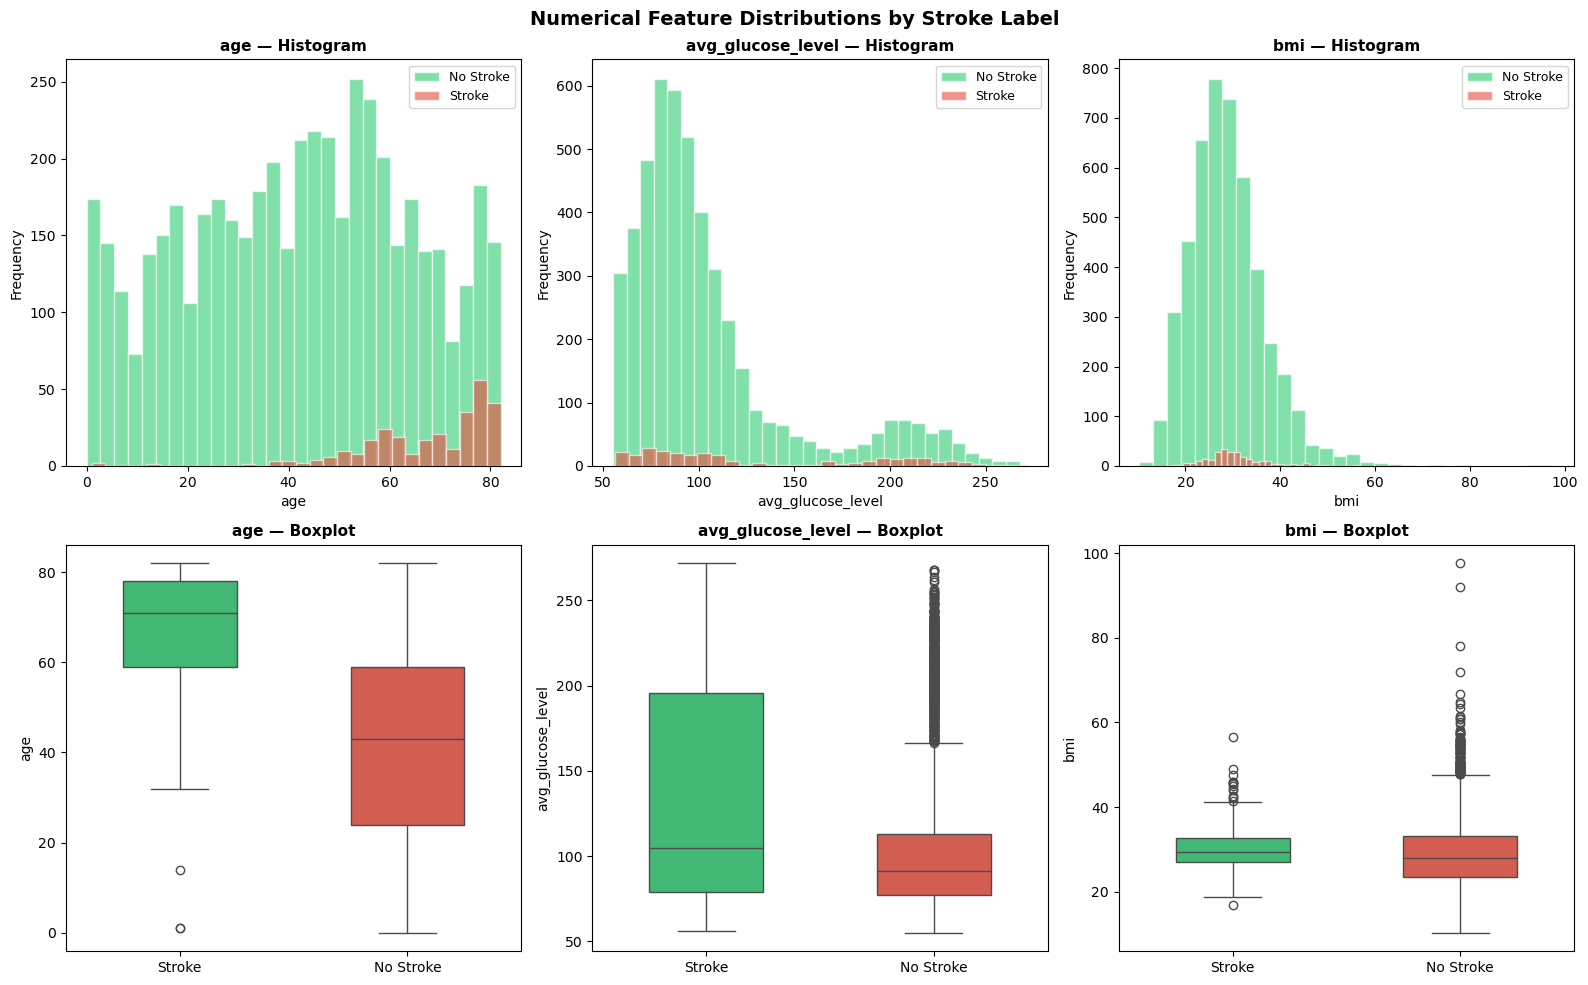

In [52]:
numerical_features = ['age', 'avg_glucose_level', 'bmi']
stroke_labels      = {0: 'No Stroke', 1: 'Stroke'}
colors             = {0: '#2ecc71', 1: '#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, feature in enumerate(numerical_features):

    ax_hist = axes[0, col_idx]
    for stroke_val, label in stroke_labels.items():
        ax_hist.hist(data[data['stroke'] == stroke_val][feature].dropna(),
                     bins=30, alpha=0.6, label=label,
                     color=colors[stroke_val], edgecolor='white')
    ax_hist.set_title(f'{feature} — Histogram', fontsize=11, fontweight='bold')
    ax_hist.set_xlabel(feature)
    ax_hist.set_ylabel('Frequency')
    ax_hist.legend(fontsize=9)

    ax_box = axes[1, col_idx]

    plot_data = data[['stroke', feature]].dropna().copy()
    plot_data['Stroke Label'] = plot_data['stroke'].map(stroke_labels)
    sns.boxplot(data=plot_data, x='Stroke Label', y=feature,
                palette=colors.values(), ax=ax_box, width=0.5)
    ax_box.set_title(f'{feature} — Boxplot', fontsize=11, fontweight='bold')
    ax_box.set_xlabel('')

plt.suptitle('Numerical Feature Distributions by Stroke Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/01_numerical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
print(data.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


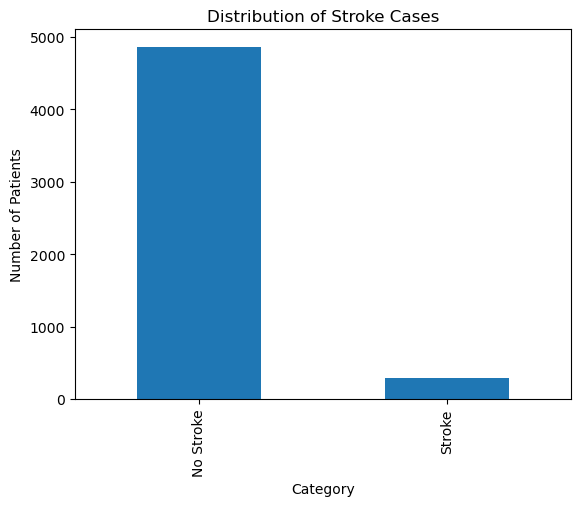

In [54]:
stroke_counts = data['stroke'].value_counts()

stroke_counts.index = ['No Stroke', 'Stroke']

stroke_counts.plot(kind='bar')

plt.title("Distribution of Stroke Cases")
plt.xlabel("Category")
plt.ylabel("Number of Patients")

plt.show()

In [55]:
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

print(data.isnull().sum())

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [56]:
data.drop_duplicates(inplace=True)

print(data.shape)

(5150, 11)


In [57]:
data = data[data['gender'] != 'Other']
data.reset_index(drop=True, inplace=True)
print(data.shape)

(5149, 11)


In [58]:
data.to_csv("new-cleaned_data.csv", index=False)

In [59]:
categorical_cols = ['gender', 'ever_married', 'work_type',
                    'Residence_type', 'smoking_status']
numerical_cols   = ['age', 'hypertension', 'heart_disease',
                    'avg_glucose_level', 'bmi']

X = data.drop(columns=['stroke'])
y = data['stroke']

In [60]:
X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

In [61]:
def print_distribution(y_series, label):
    counts = y_series.value_counts()
    pct    = y_series.value_counts(normalize=True) * 100


In [62]:
preprocessor = ColumnTransformer(transformers=[
    ('onehot',  OneHotEncoder(drop='first', sparse_output=False,handle_unknown='ignore'),categorical_cols,),
    ('scaler',  StandardScaler(),numerical_cols)
], remainder='drop')

In [63]:
preprocessor.fit(X_raw_train)

,transformers,"[('onehot', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [64]:
X_train = preprocessor.transform(X_raw_train)
X_test  = preprocessor.transform(X_raw_test)

In [65]:
encoded_feature_names = (
    preprocessor.named_transformers_['onehot']
    .get_feature_names_out(categorical_cols).tolist()
)
all_feature_names = encoded_feature_names + numerical_cols

In [66]:
X_train = pd.DataFrame(X_train, columns=all_feature_names)
X_test  = pd.DataFrame(X_test,  columns=all_feature_names)

In [67]:
no_stroke_count = (y_train == 0).sum()
stroke_count = (y_train == 1).sum()

In [68]:
stroke_weight = round(no_stroke_count / stroke_count, 2)


In [69]:
#logistic regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [70]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [71]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced_subsample',   # ← key fix for zero-recall problem
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [72]:
rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
xgb_model = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=stroke_weight,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

In [74]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [75]:
os.makedirs('outputs', exist_ok=True)

In [76]:
def find_best_threshold(model, X_tr, y_tr):
    proba   = model.predict_proba(X_tr)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_tr, proba)
    j_scores = tpr - fpr
    best_idx  = np.argmax(j_scores)
    return round(thresholds[best_idx], 4)

lr_threshold  = find_best_threshold(lr_model,  X_train, y_train)
rf_threshold  = find_best_threshold(rf_model,  X_train, y_train)
xgb_threshold = find_best_threshold(xgb_model, X_train, y_train)

In [77]:
def evaluate_model(name, model, X_test_data, Y_test_data, threshold=0.5):
    y_probabilities = model.predict_proba(X_test_data)[:, 1]
    y_predictions = (y_probabilities >= threshold).astype(int)

    #evaluation metrics
    accuracy  = accuracy_score(Y_test_data, y_predictions)
    precision = precision_score(Y_test_data, y_predictions, zero_division=0)
    recall    = recall_score(Y_test_data, y_predictions, zero_division=0)
    f1 = f1_score(Y_test_data, y_predictions, zero_division=0)
    roc_auc   = roc_auc_score(Y_test_data, y_probabilities)
    confusion_mat = confusion_matrix(Y_test_data, y_predictions)
    true_neg, false_pos, false_neg, true_pos = confusion_mat.ravel()

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}\n(threshold={threshold})')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    safe = name.replace(' ', '_').lower()
    plt.savefig(f'outputs/confusion_matrix_{safe}.png', dpi=150)
    plt.close()

    return {
        'Model'    : name,
        'Threshold': threshold,
        'Accuracy' : accuracy,
        'Precision': precision,
        'Recall'   : recall,
        'F1 Score' : f1,
        'ROC-AUC'  : roc_auc,
        '_y_proba' : y_probabilities,
    }


In [78]:
evaluate_model("Logistic Regression", lr_model, X_test, y_test)
evaluate_model("Random Forest", rf_model, X_test, y_test)
evaluate_model("XGBoost", xgb_model, X_test, y_test)

{'Model': 'XGBoost',
 'Threshold': 0.5,
 'Accuracy': 0.8436893203883495,
 'Precision': 0.2154696132596685,
 'Recall': 0.6724137931034483,
 'F1 Score': 0.3263598326359833,
 'ROC-AUC': 0.8397190293742017,
 '_y_proba': array([4.9224850e-03, 8.9093540e-03, 7.9051002e-05, ..., 3.0019672e-03,
        2.2871202e-01, 6.1626430e-04], shape=(1030,), dtype=float32)}

In [ ]:
results_80 = []
results_80.append(evaluate_model('Logistic Regression', lr_model,  X_test, y_test, lr_threshold))
results_80.append(evaluate_model('Random Forest', rf_model,  X_test, y_test, rf_threshold))
results_80.append(evaluate_model('XGBoost', xgb_model, X_test, y_test, xgb_threshold))

In [80]:
for res in results_80:
    fig, ax = plt.subplots(figsize=(6, 5))
    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {res['ROC-AUC']:.4f}")
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.50)')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f"ROC Curve — {res['Model']}")
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    safe = res['Model'].replace(' ', '_').lower()
    plt.savefig(f'outputs/roc_curve_{safe}_8020.png', dpi=150)
    plt.close()

In [81]:
X_temp,    X_test_70, y_temp,    y_test_70 = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)

X_train_70, X_val_70, y_train_70, y_val_70 = train_test_split(
    X_temp, y_temp, test_size=0.2222, random_state=42, stratify=y_temp)

In [82]:
preprocessor_70 = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
    ('scaler', StandardScaler(),                                  numerical_cols)
], remainder='drop')

preprocessor_70.fit(X_train_70)

X_tr70  = pd.DataFrame(preprocessor_70.transform(X_train_70), columns=all_feature_names)
X_val70 = pd.DataFrame(preprocessor_70.transform(X_val_70),   columns=all_feature_names)
X_te70  = pd.DataFrame(preprocessor_70.transform(X_test_70),  columns=all_feature_names)


In [83]:
neg70  = (y_train_70 == 0).sum()
pos70  = (y_train_70 == 1).sum()
spw70  = round(neg70 / pos70, 2)

lr70  = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf70  = RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample',
                                min_samples_leaf=2, random_state=42, n_jobs=-1)
xgb70 = XGBClassifier(n_estimators=300, scale_pos_weight=spw70, max_depth=4,
                       learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                       use_label_encoder=False, eval_metric='logloss',
                       random_state=42, verbosity=0)

for name, model in [('Logistic Regression', lr70), ('Random Forest', rf70), ('XGBoost', xgb70)]:
    model.fit(X_tr70, y_train_70)


lr70_thr  = find_best_threshold(lr70,  X_tr70, y_train_70)
rf70_thr  = find_best_threshold(rf70,  X_tr70, y_train_70)
xgb70_thr = find_best_threshold(xgb70, X_tr70, y_train_70)

In [84]:
results_val70 = []
results_val70.append(evaluate_model('Logistic Regression [Val]', lr70,  X_val70, y_val_70, lr70_thr))
results_val70.append(evaluate_model('Random Forest [Val]',        rf70,  X_val70, y_val_70, rf70_thr))
results_val70.append(evaluate_model('XGBoost [Val]',              xgb70, X_val70, y_val_70, xgb70_thr))

In [85]:
results_test70 = []
results_test70.append(evaluate_model('Logistic Regression [Test70]', lr70,  X_te70, y_test_70, lr70_thr))
results_test70.append(evaluate_model('Random Forest [Test70]',        rf70,  X_te70, y_test_70, rf70_thr))
results_test70.append(evaluate_model('XGBoost [Test70]',              xgb70, X_te70, y_test_70, xgb70_thr))

In [86]:
results_clean = [{k: v for k, v in r.items()
                  if not k.startswith('_')}
                 for r in results_80]          # ← use results_80, not optuna

results_df = pd.DataFrame(results_clean).set_index('Model')

print('\n📊 Final Model Comparison:')
print(results_df[['Accuracy','Precision','Recall',
                   'F1 Score','ROC-AUC']].round(4).to_string())

# Select best model by Recall (clinical priority)
best_model_name = results_df['Recall'].idxmax()
best_auc        = results_df.loc[best_model_name, 'ROC-AUC']
best_recall     = results_df.loc[best_model_name, 'Recall']

print(f'\n🏆 Best Model : {best_model_name}')
print(f'   Recall     : {best_recall:.4f}')
print(f'   ROC-AUC    : {best_auc:.4f}')

model_map = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model,
}
best_model = model_map[best_model_name]



📊 Final Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7136     0.1463  0.8448    0.2494   0.8232
Random Forest          0.9447     0.5385  0.1207    0.1972   0.8416
XGBoost                0.8845     0.2348  0.4655    0.3121   0.8397

🏆 Best Model : Logistic Regression
   Recall     : 0.8448
   ROC-AUC    : 0.8232


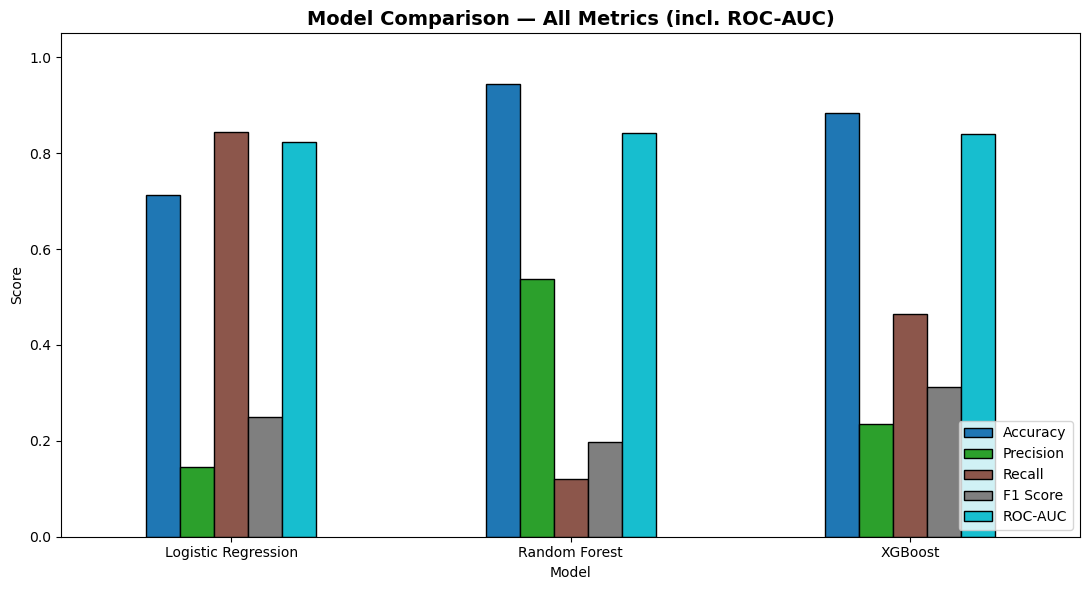

In [87]:
# ── MODEL COMPARISON BAR CHART ──
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
results_df[metrics_to_plot].plot(kind='bar', figsize=(11, 6),
                                 colormap='tab10', edgecolor='black')
plt.title('Model Comparison — All Metrics (incl. ROC-AUC)',
          fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150)
plt.show()


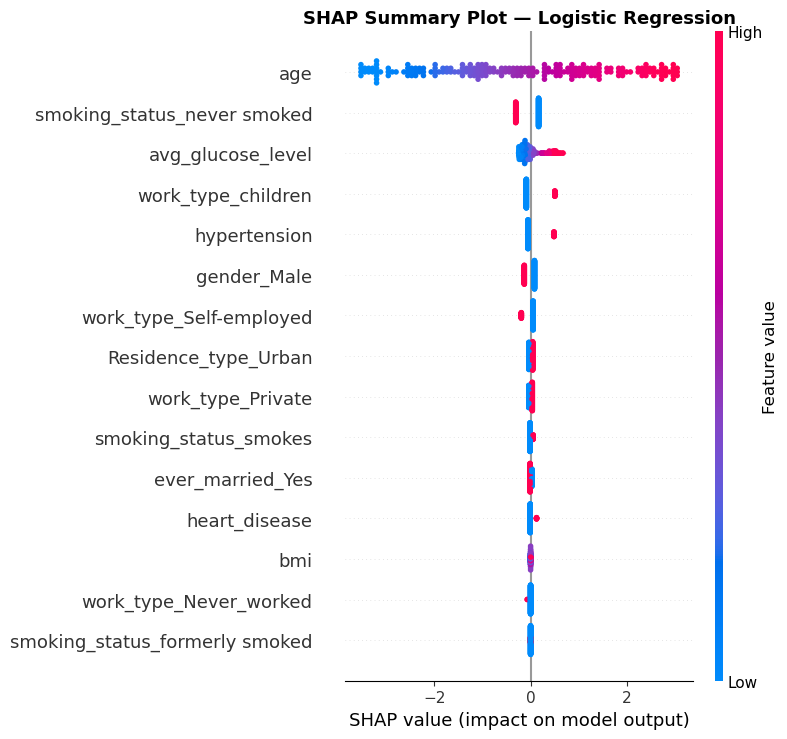

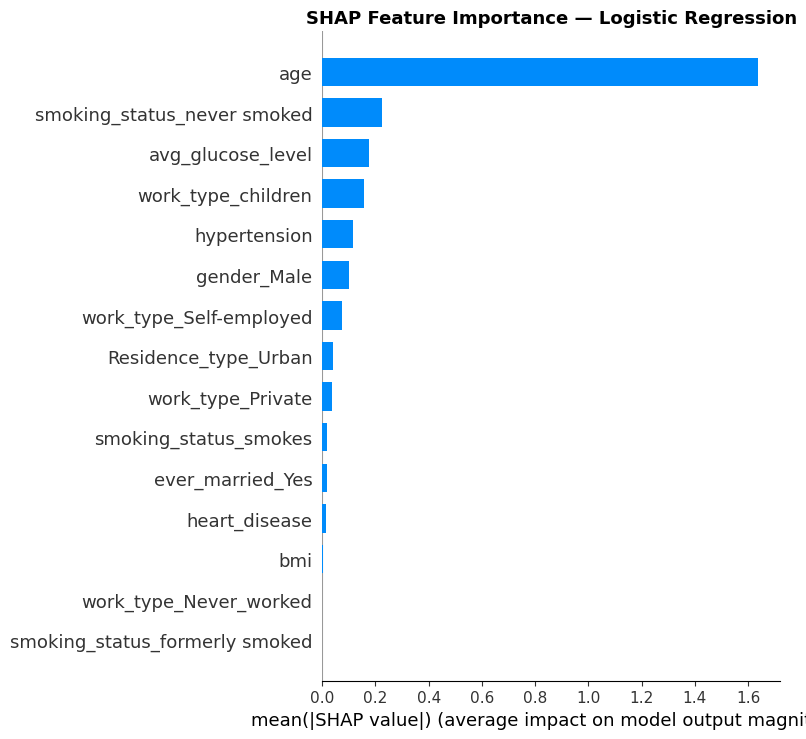

In [88]:
sample_size = min(200, len(X_test))
X_sample    = X_test.iloc[:sample_size].reset_index(drop=True)

if best_model_name in ("Random Forest", "XGBoost"):
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)
    shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    explainer   = shap.LinearExplainer(best_model, X_train,
                                        feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_sample)
    shap_vals   = shap_values
plt.figure()
shap.summary_plot(shap_vals, X_sample, feature_names=all_feature_names, show=False)
plt.title(f'SHAP Summary Plot — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_vals, X_sample, feature_names=all_feature_names,
                  plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

mean_shap     = shap_vals.mean(axis=0)
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature'    : all_feature_names,
    'Mean SHAP'  : mean_shap.round(4),
    'Mean |SHAP|': mean_abs_shap.round(4),
    'Direction'  : ['Increases Risk' if v > 0 else 'Decreases Risk' for v in mean_shap]
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)